"""
Test: Multiline Voigt Sampling Validation

Author
------
Leila Alston

Description
-----------
This script validates the multiline Voigt random wavelength sampling
algorithm by comparing the analytical multiline Voigt spectrum to the
distribution of randomly sampled wavelengths.

The Workflow
-----------
    1. Define a set of spectral lines with known locations,
       relative intensities, Gaussian widths (sigma), and
       Lorentzian widths (gamma).
    2. Construct the cumulative distribution function (CDF) of the
       multiline Voigt spectrum.
    3. Generate a large number of random wavelength samples using
       inverse CDF sampling.
    4. Compare the sampled wavelength distribution against the
       original analytical spectrum.

Purpose
-------
This validation confirms that:
    • multiline_voigt_cdf_tab() correctly constructs the spectrum.
    • multiline_voigt_random() samples wavelengths according to the
      expected probability distribution.
    • The sampled histogram reproduces the analytical multiline
      Voigt profile.

Notes
-----
This script does not perform ray tracing. It validates only the
random wavelength sampling algorithm before integration into the
XICSRT raytracing framework.
"""

In [2]:
# Setup the module path.
import sys
sys.path.append(r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xics_ml_pipeline")

from xicsrt_multiline_voigt import voigt, multiline_voigt, multiline_voigt_cdf_tab, multiline_voigt_random

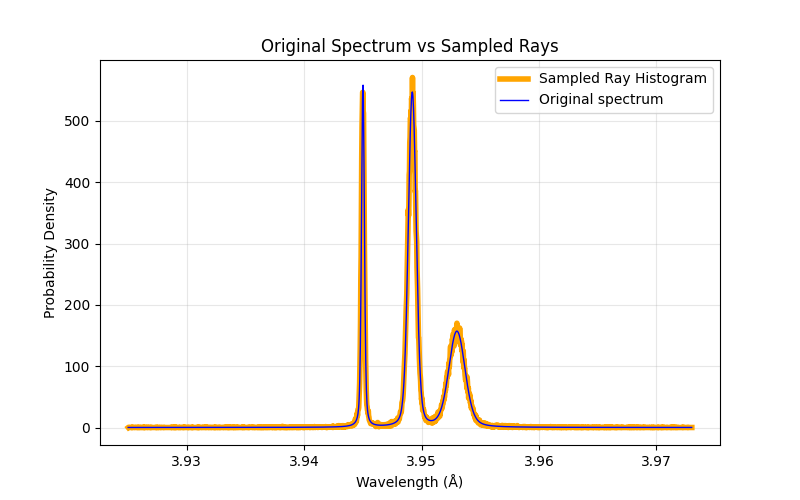

In [3]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

# Three test Voigt lines
line_locations = np.array([3.945, 3.9492, 3.953])
line_intensities = np.array([0.4, 1.0, 0.6])

sigmas = np.array([0.00010, 0.00030, 0.00060])
gammas = np.array([0.00005, 0.00008, 0.00020])

# ------------------------------------------------------------
# Build CDF and spectrum
# ------------------------------------------------------------
cdf_x, cdf, spectrum = multiline_voigt_cdf_tab(
    line_locations,
    line_intensities,
    sigmas,
    gammas,
)
# print(len(cdf_x))

# ------------------------------------------------------------
# Sample ray wavelengths
# ------------------------------------------------------------
sampled_wavelengths = multiline_voigt_random(
    line_locations,
    line_intensities,
    sigmas,
    gammas,
    size=100000,
)

# Required step is normalizing the spectrum if 'plt.hist(..., density=True,...)'
spectrum_pdf = spectrum / np.trapezoid(spectrum, cdf_x)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

"""
# Histogram of sampled ray wavelengths
plt.hist(
    sampled_wavelengths,
    bins=300,
    density=True,
    histtype='bar',
    edgecolor='orange',
    linewidth=0.3,
    alpha=0.5,
    color='orange',
    label='Sampled ray histogram',
)
"""

# Calculating the histogram and plotting as line
hist_counts, hist_edges = np.histogram(
    sampled_wavelengths, 
    bins=np.append(cdf_x, cdf_x[-1] + (cdf_x[1] - cdf_x[0])), 
    density = True,
)
hist_centers = 0.5 * (hist_edges[:-1] + hist_edges[1:])
plt.plot(
    hist_centers, 
    hist_counts, 
    color = 'orange',
    linewidth = 4, 
    label = 'Sampled Ray Histogram',
)


# Original multi-line spectrum
plt.plot(
    cdf_x,
    spectrum_pdf,
    color='blue',
    linewidth=1,
    # marker='o',
    label='Original spectrum',
)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Probability Density")
plt.title("Original Spectrum vs Sampled Rays")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

INFO:xicsrt.xicsrt_raytrace:Starting run: 1 of 1
INFO:xicsrt.xicsrt_raytrace:Seeding np.random with None


Using sampled wavelength: 3.9581250054553405


INFO:xicsrt.xicsrt_raytrace:Starting iteration: 1 of 1
C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\DESC\desc\vmec.py:93: UserWarning: VMEC output appears to be from version 8.48 while DESC is only designed for compatibility with VMEC version 9. Some data may not be loaded correctly.
  warnings.warn(
INFO:xicsrt.xicsrt_io:Saved image: C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_crystal__00_0000.tif
INFO:xicsrt.xicsrt_io:Saved image: C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_detector__00_0000.tif
INFO:xicsrt.xicsrt_io:Saved image: C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_crystal__00.tif
INFO:xicsrt.xicsrt_io:Saved image: C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_detector__00.tif



Rays Generated: 4.498e+05
Rays Detected:  1.090e+02
Efficiency:     2.423e-04 ± 2.3e-05 (0.02423%)



INFO:xicsrt.util.profiler:name                      total           single          calls 
INFO:xicsrt.util.profiler:raytrace                  0:01:09.841206  0:01:09.841206       1
INFO:xicsrt.util.profiler:raytrace_single           0:01:09.813157  0:01:09.813157       1
INFO:xicsrt.util.profiler:_raytrace_iter            0:01:04.589083  0:01:04.589083       1
INFO:xicsrt.util.profiler:Bundle Input Generation   0:00:42.541864  0:00:42.541864       1
INFO:xicsrt.util.profiler:Fluxspace from Realspace  0:00:42.540637  0:00:42.540637       1
INFO:xicsrt.util.profiler:Ray Bundle Generation     0:00:02.356534  0:00:00.000720    3274
INFO:xicsrt.util.profiler:generate_rays             0:00:01.849021  0:00:00.000565    3274
INFO:xicsrt.util.profiler:generate_wavelength       0:00:01.011998  0:00:00.000309    3274
INFO:xicsrt.util.profiler:generate_direction        0:00:00.616883  0:00:00.000188    3274
INFO:xicsrt.util.profiler:Dispatcher: raytrace      0:00:00.320282  0:00:00.320282       1

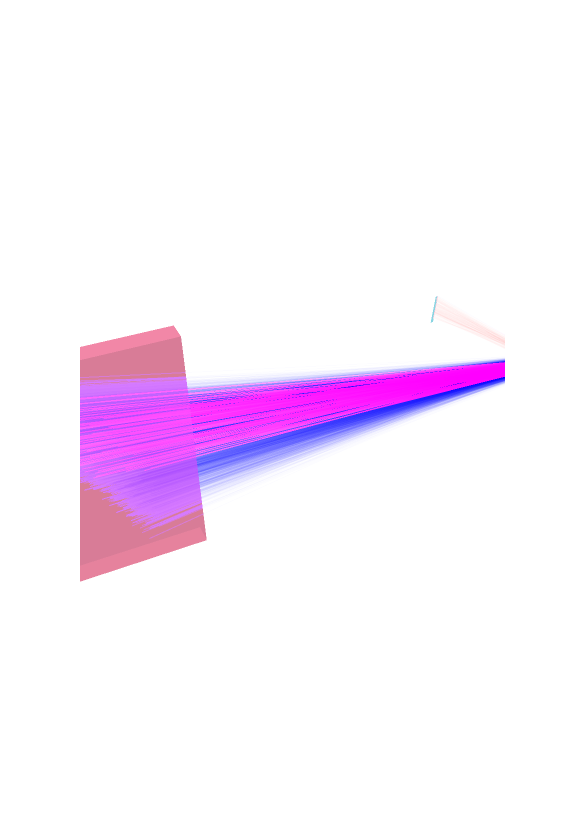

In [4]:
%matplotlib widget
import numpy as np
from collections import OrderedDict
import os

# Setup the module path.
import sys
sys.path.append(r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt")
sys.path.append(r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_contrib")
sys.path.append(r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_analysis")
sys.path.append(r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\mirfusion_library")

## Start Logging
import logging
logging.basicConfig(level=logging.DEBUG)
logging.getLogger('matplotlib').setLevel(logging.WARNING)
logging.getLogger('PIL').setLevel(logging.WARNING)
logging.getLogger('h5py').setLevel(logging.WARNING)
logging.getLogger('jax').setLevel(logging.WARNING)

from mirutil import mirprint

# Import xicsrt modules
import xicsrt
from xicsrt.util import profiler

from w7x_npablant import xicsrt_w7x_npablant

# import the multilin Voigt function here
# change this import path to wherever the function is placed
# from xicsrt.tools.xicsrt_voigt import multiline_voigt_random

config = xicsrt_w7x_npablant.get_config()
config = xicsrt_w7x_npablant.initialize(config)

config['general']['comment'] = """
W7-X run without velocity profile profile.
Based on Op1.2b geometry calibration.

Simple polynomial profiles for emissivity, temperature and velocity.

Full crystal W7-X Ar16+ raytracing simulation with realistic W7-X plasma geometry.
"""

config['general']['number_of_runs'] = 1
config['general']['number_of_iter'] = 1
config['general']['save_images'] = True
config['general']['make_directories'] = True
config['general']['keep_history'] = True

config['general']['output_path'] = r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026"
config['general']['output_suffix'] = '_00'

config['sources']['plasma']['wout_file'] = r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\wout.nc"
config['sources']['plasma']['enable_velocity'] = False
config['sources']['plasma']['enable_flux_compression'] = False
config['sources']['plasma']['time_resolution'] = 1e-3
config['sources']['plasma']['spread'] = np.radians(1.0)
config['sources']['plasma']['xsize'] = 0.15

# ------------------------------------------------------------
# Multi-Voigt sampled wavelength test
# ------------------------------------------------------------

line_locations = np.array([3.9492, 3.9660, 3.9695, 3.9944])
line_intensities = np.array([1.0, 0.5, 0.5, 0.3])
sigmas = np.array([0.002, 0.002, 0.002, 0.002])
gammas = np.array([0.001, 0.001, 0.001, 0.001])

sampled_wavelengths = multiline_voigt_random(
    line_locations,
    line_intensities,
    sigmas,
    gammas,
    size=1,
    gridsize=None,
    cutoff=1e-4,
)

# making each ray emitted from the plasma use the same wavelength
# if we want each ray to get its own sampled wavelength, then 'size=num_rays'
config['sources']['plasma']['wavelength'] = sampled_wavelengths[0]

print("Using sampled wavelength:", config['sources']['plasma']['wavelength'])

# ------------------------------------------------------------
# Raytrace
# ------------------------------------------------------------

profiler.resetProfiler()
profiler.startProfiler()

result = xicsrt.raytrace(config)
    
profiler.stopProfiler()
profiler.report()

import xicsrt.visual.xicsrt_3d__plotly as xicsrt_3d

fig = xicsrt_3d.figure()
# xicsrt_3d.add_fluxsurfaces(result['config'], range_n=(0, np.pi*2))
xicsrt_3d.add_rays(result)
xicsrt_3d.add_optics(result['config'])
xicsrt_3d.add_sources(result['config'])

fig.update_layout(
    autosize=False,
    width=1000,
    height=800,
)

xicsrt_3d.show()